In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL

In [ ]:
daily_data = pd.read_csv("Merged_cleaned_daily_data.csv")

daily_data.station_id.value_counts()

station_id
downtown     1096
helwan       1096
new_cairo    1096
october      1096
shobra       1096
Name: count, dtype: int64

In [4]:
districts = daily_data.station_id.unique()
districts

array(['downtown', 'helwan', 'new_cairo', 'october', 'shobra'],
      dtype=object)

### 1. Determine Additive or Multiplicative

Every Distribution has been plotted to see if there is any distribution that has a proportional growing or decreasing over time.

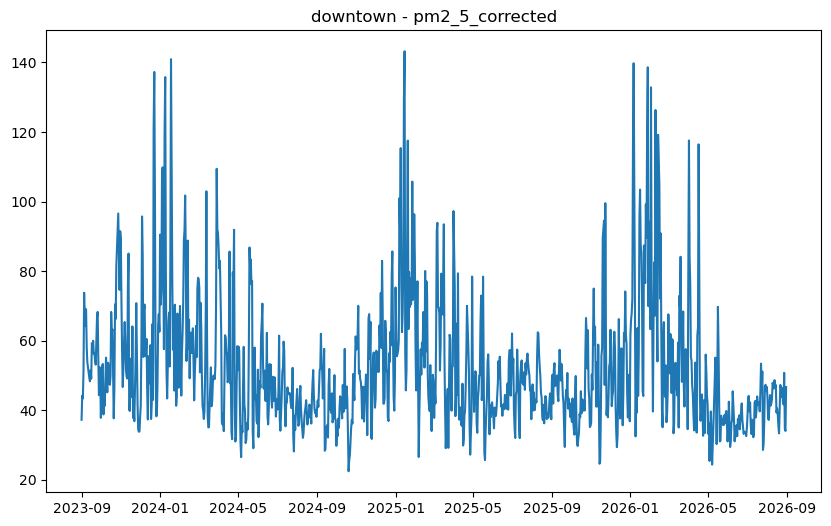

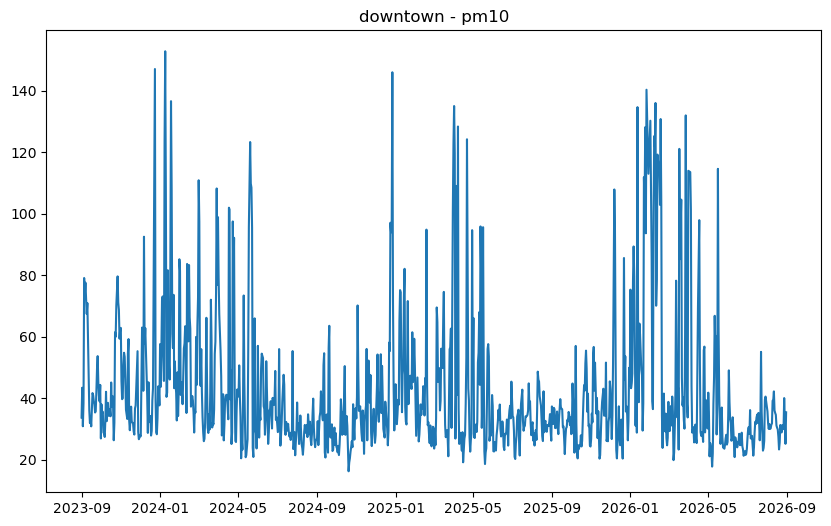

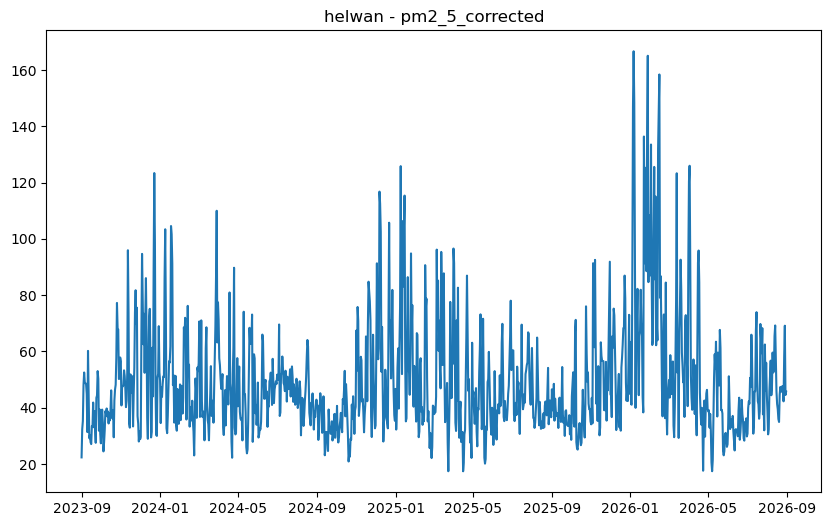

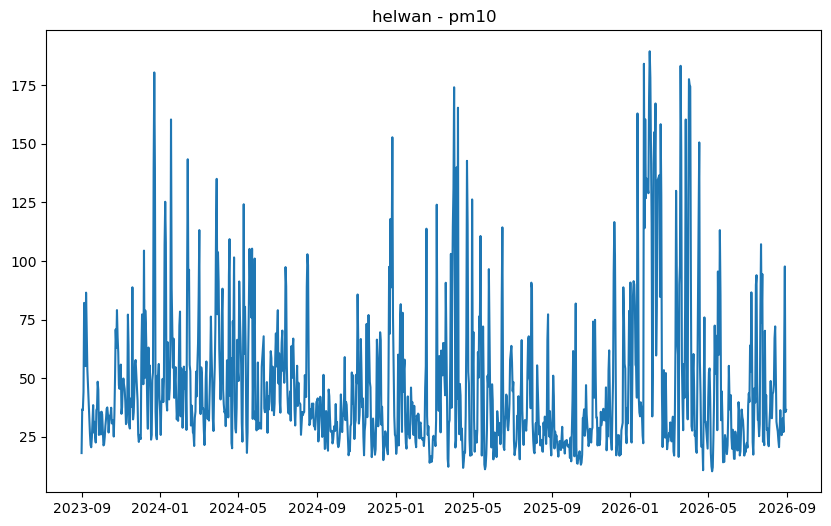

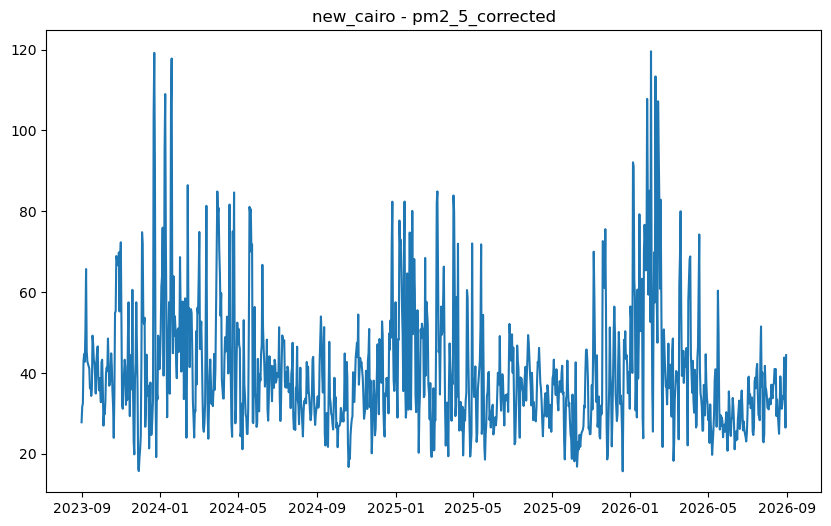

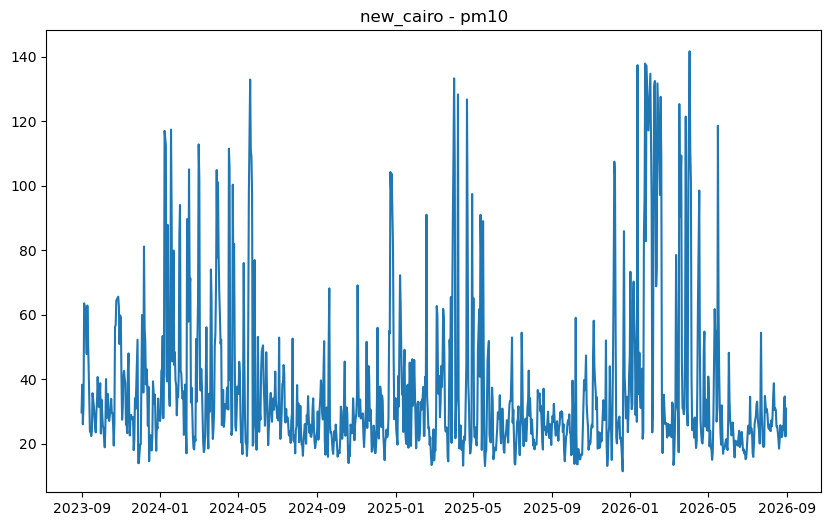

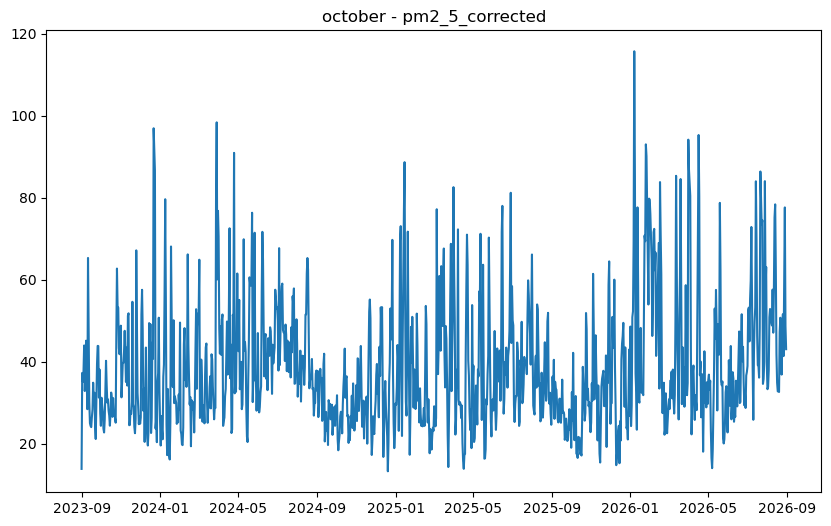

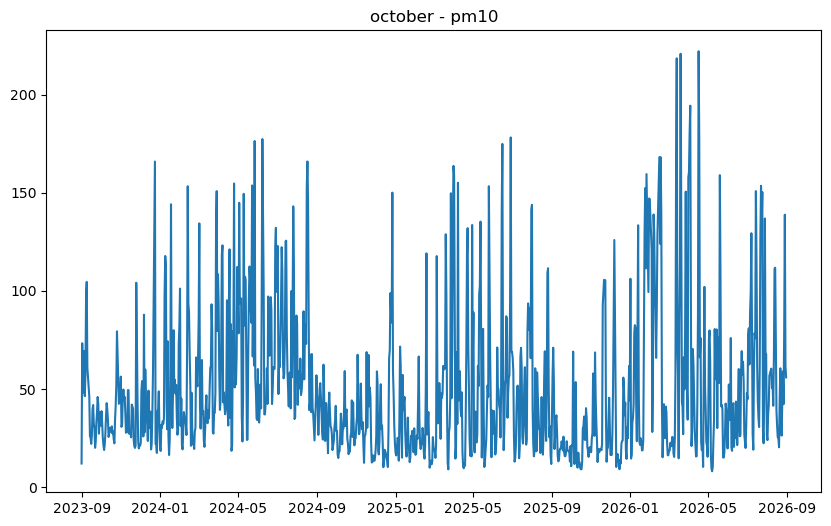

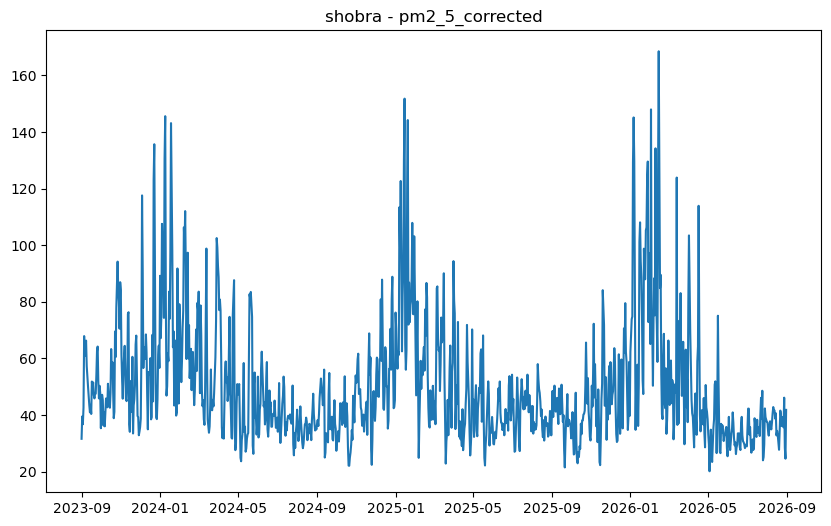

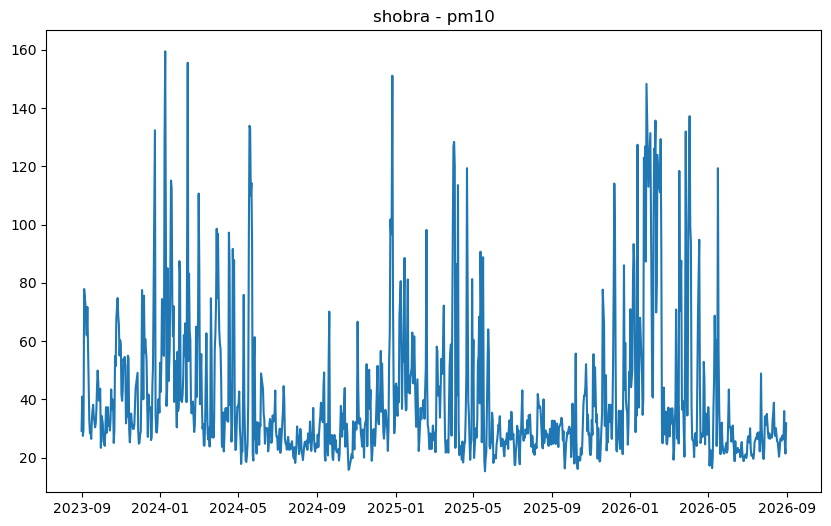

In [ ]:
targets = ['pm2_5_corrected','pm10']

# Showing the line plot of each district for each pollutant to know if it's additive or multiplicative!
for district in districts:
    # Filter for a specific district and ensure proper daily indexing
    district_df = daily_data[daily_data['station_id'] == district].copy()
    district_df['day'] = pd.to_datetime(district_df['day'])

    district_df = district_df.set_index('day').sort_index()

    # Extract the target series 
    for target in targets:
        series = district_df[target]
        fig,ax = plt.subplots()
        fig.set_figheight(6)
        fig.set_figwidth(10)

        ax.plot(series.index,series)
        ax.set_title(f"{district} - {target}")
        

**Verdict** : only helwan pm2_5 is multiplicative

In [27]:

def plot_stl_components(observed, trend, seasonal, resid, title):
    """Utility function to replicate statsmodels STL plot with transformed data."""
    fig, axes = plt.subplots(4, 1, figsize=(12, 8), sharex=True)
    
    axes[0].plot(observed)
    axes[0].set_ylabel('Observed')
    
    axes[1].plot(trend)
    axes[1].set_ylabel('Trend')
    
    axes[2].plot(seasonal)
    axes[2].set_ylabel('Season')
    
    axes[3].scatter(resid.index, resid, s=15)
    axes[3].axhline(0, color='black', linewidth=1)
    axes[3].set_ylabel('Resid')
    
    plt.suptitle(title, y=1.01, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


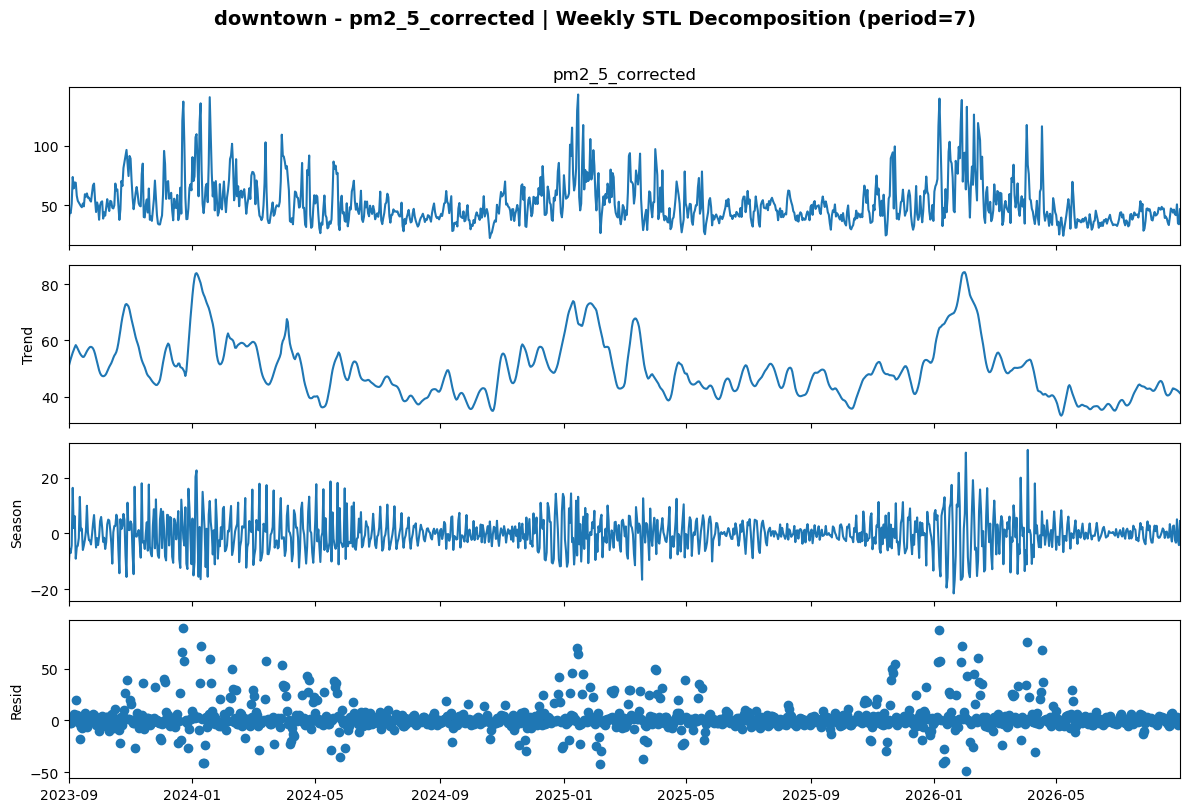

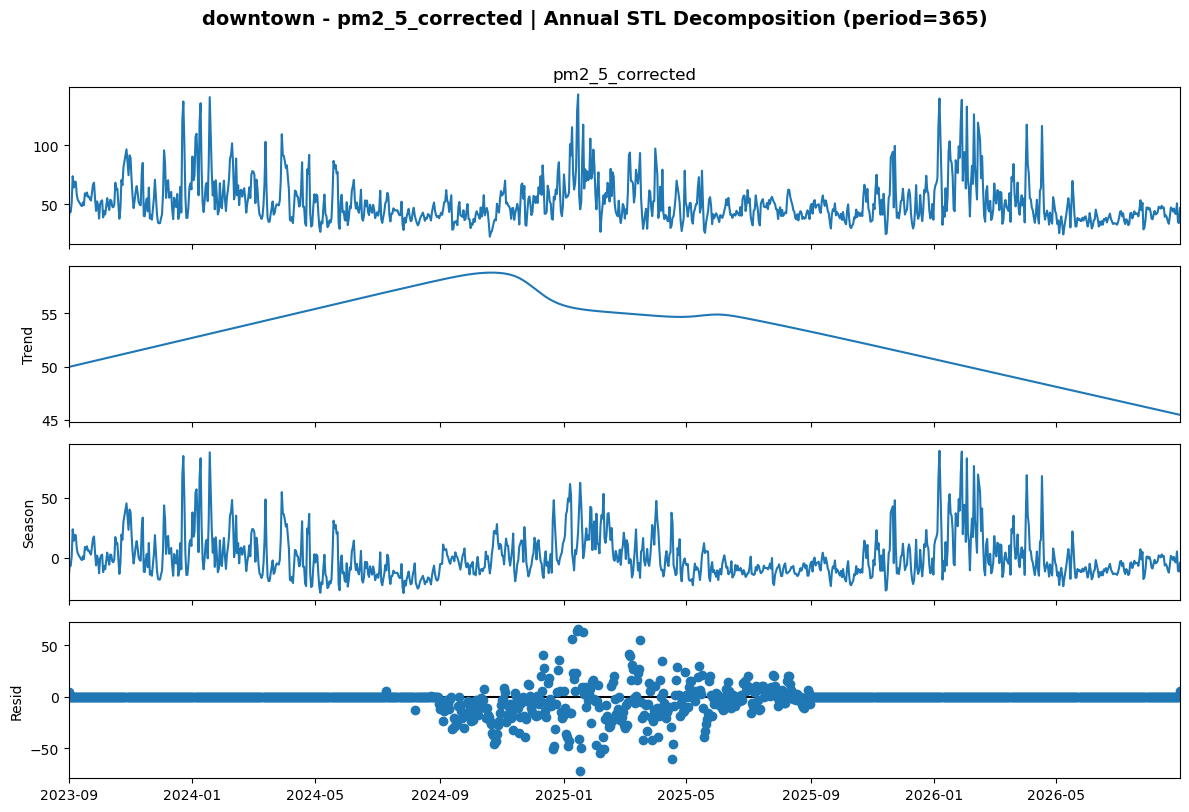

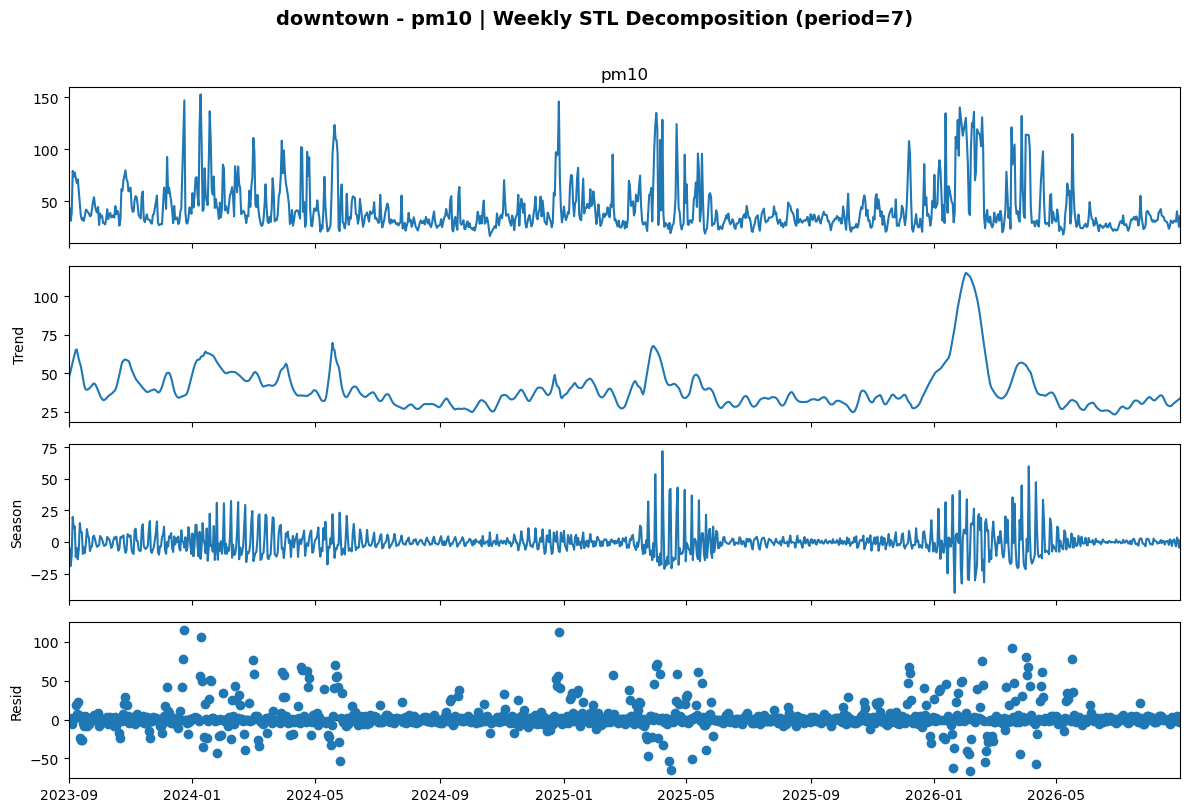

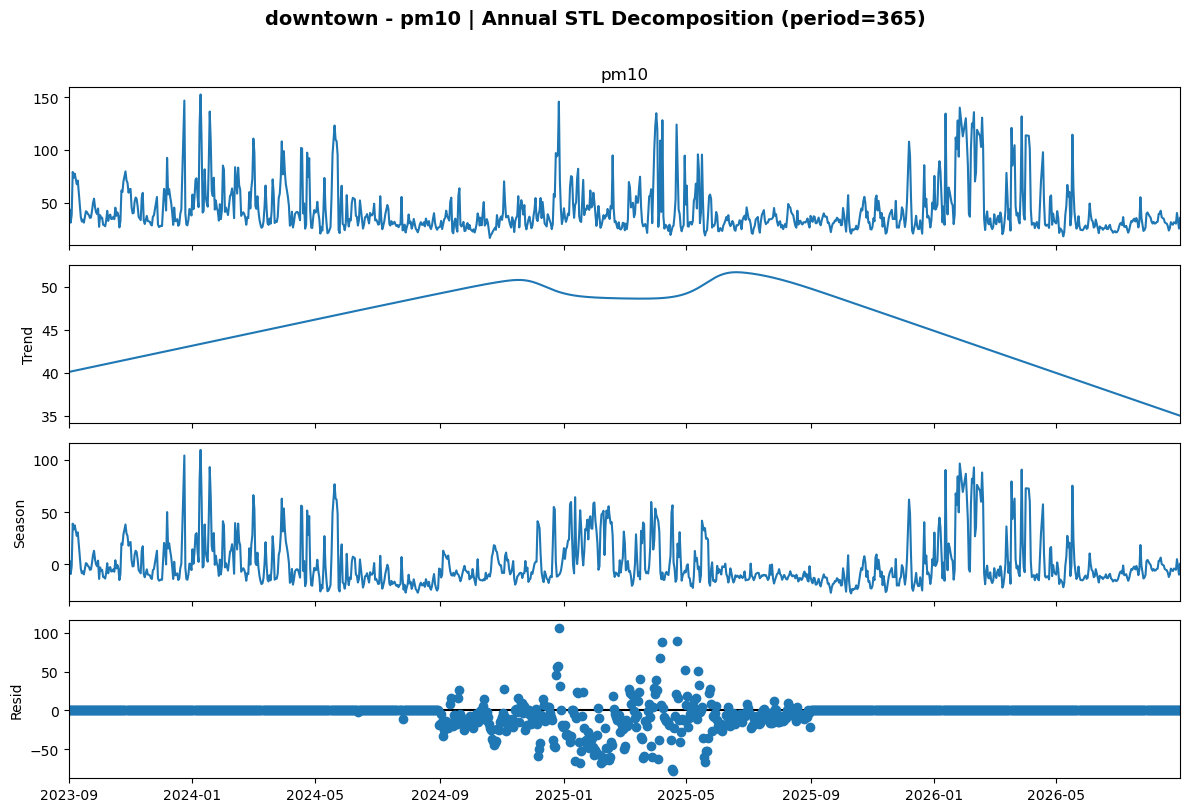

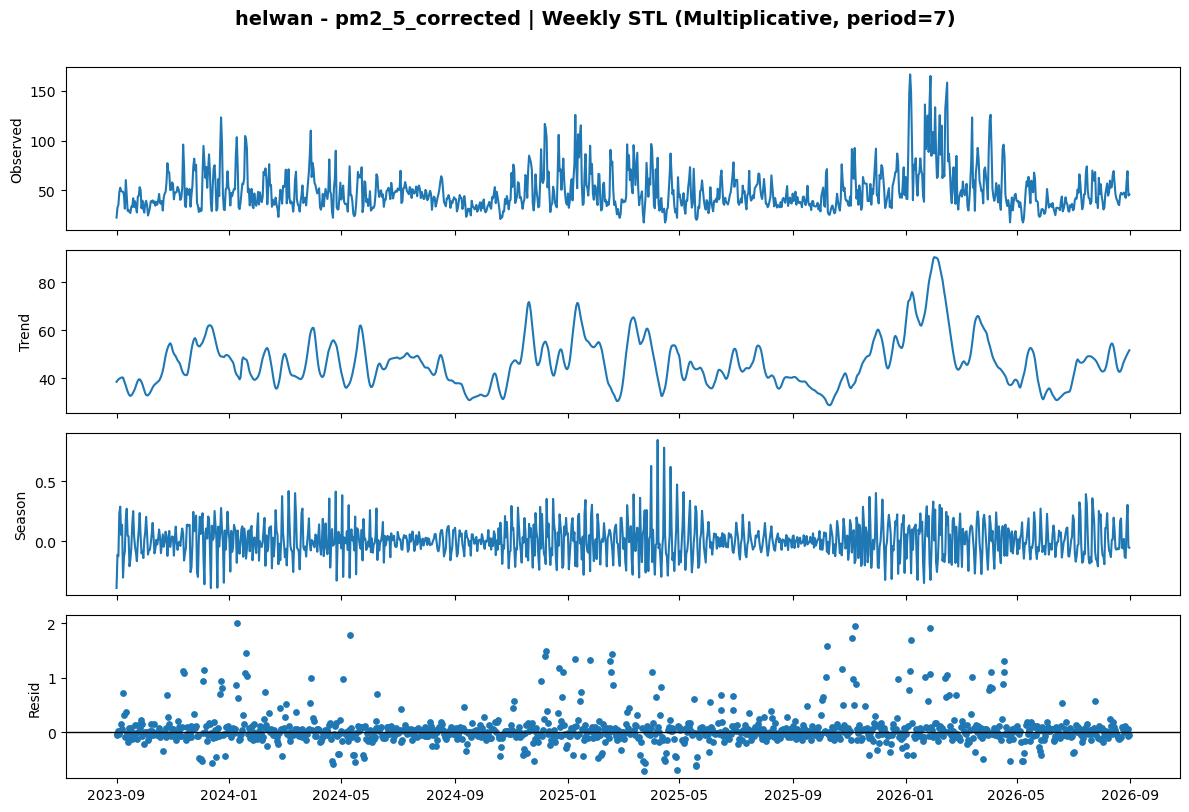

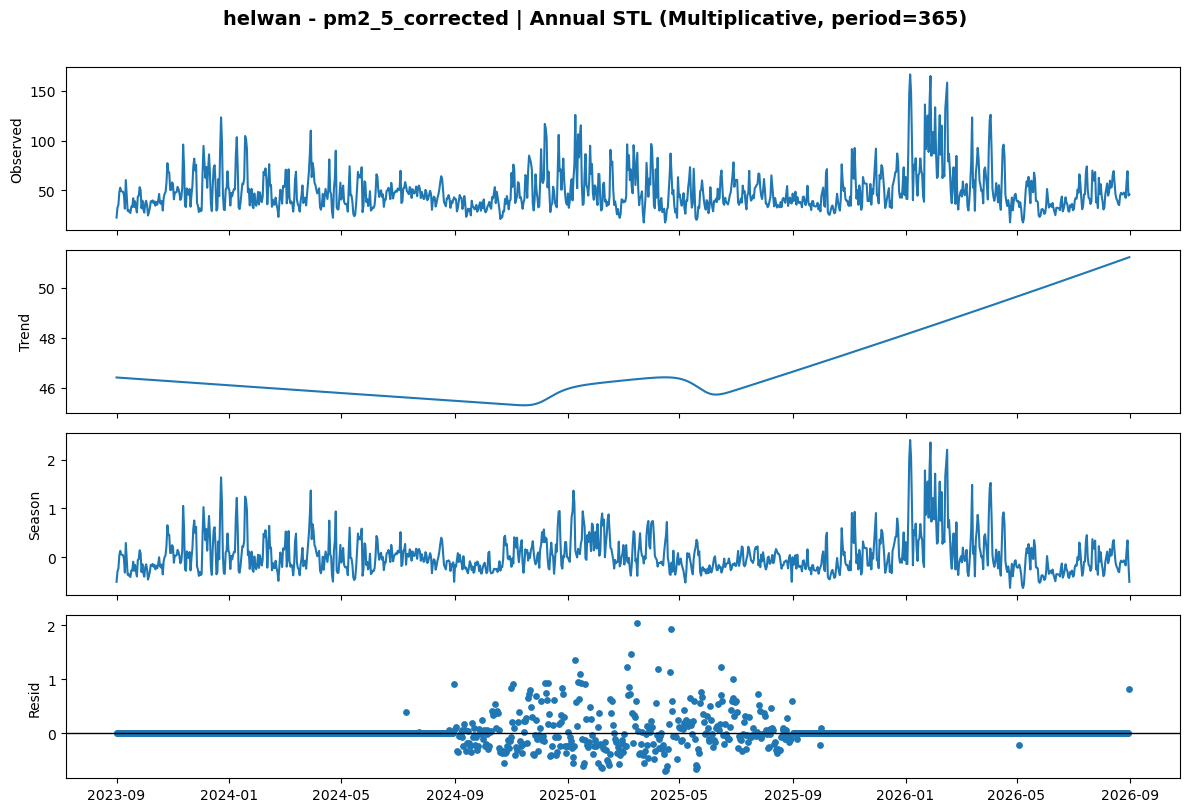

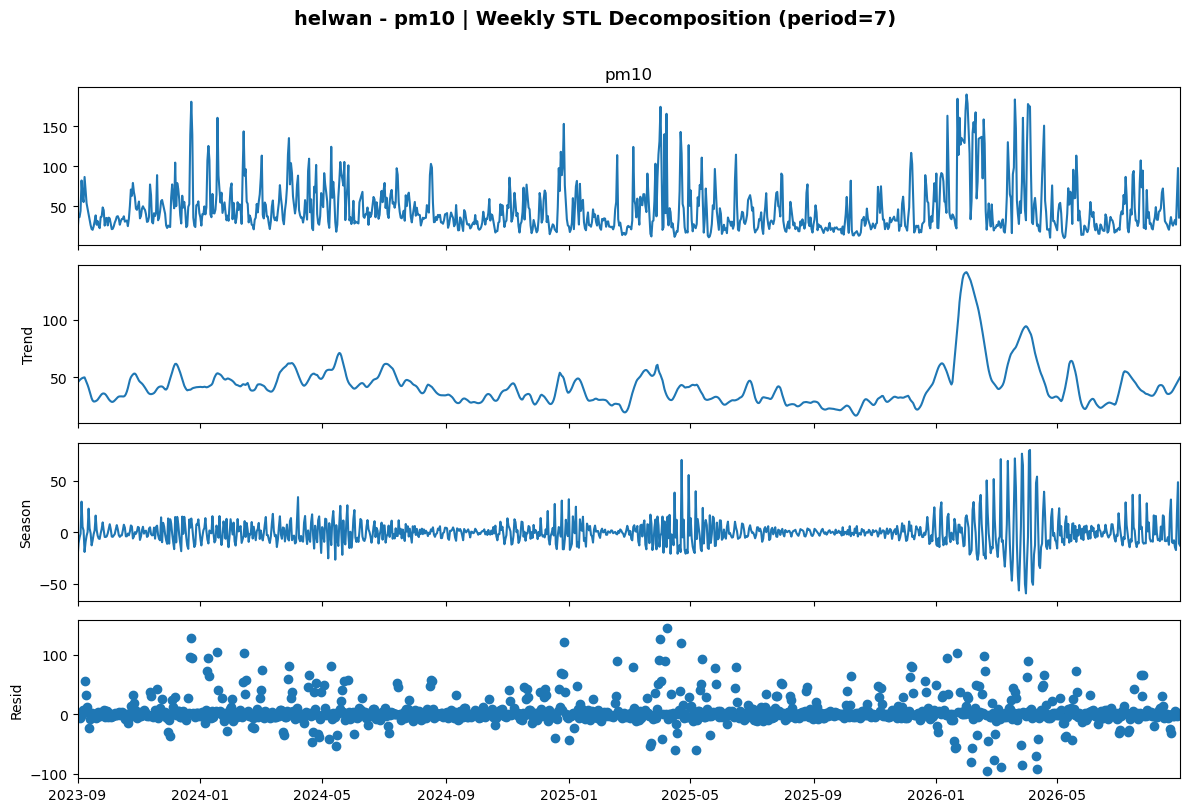

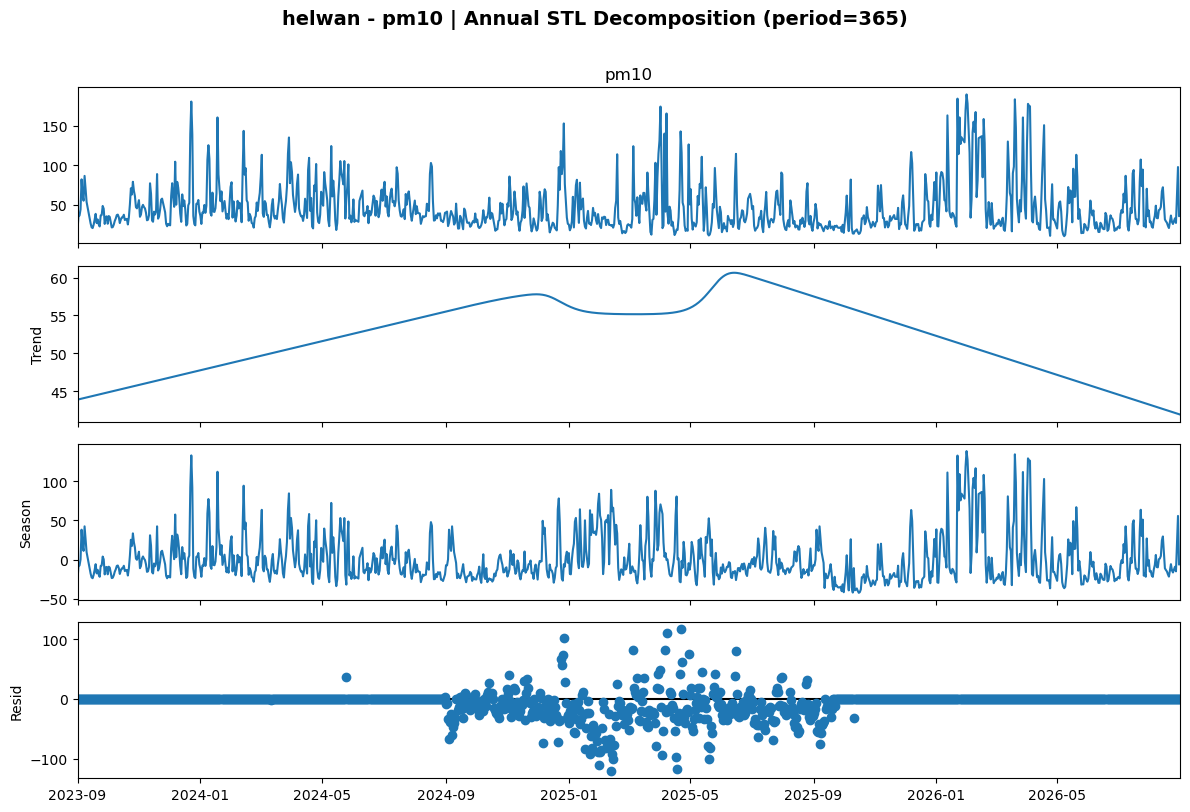

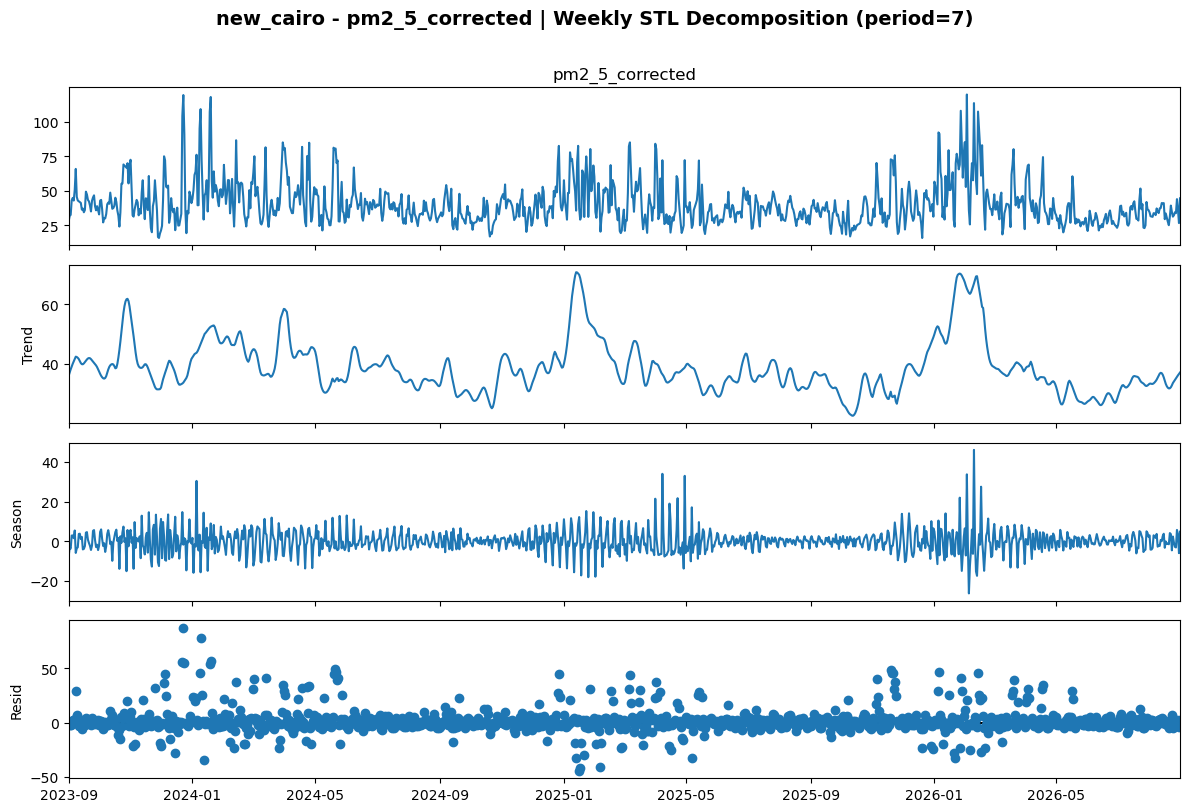

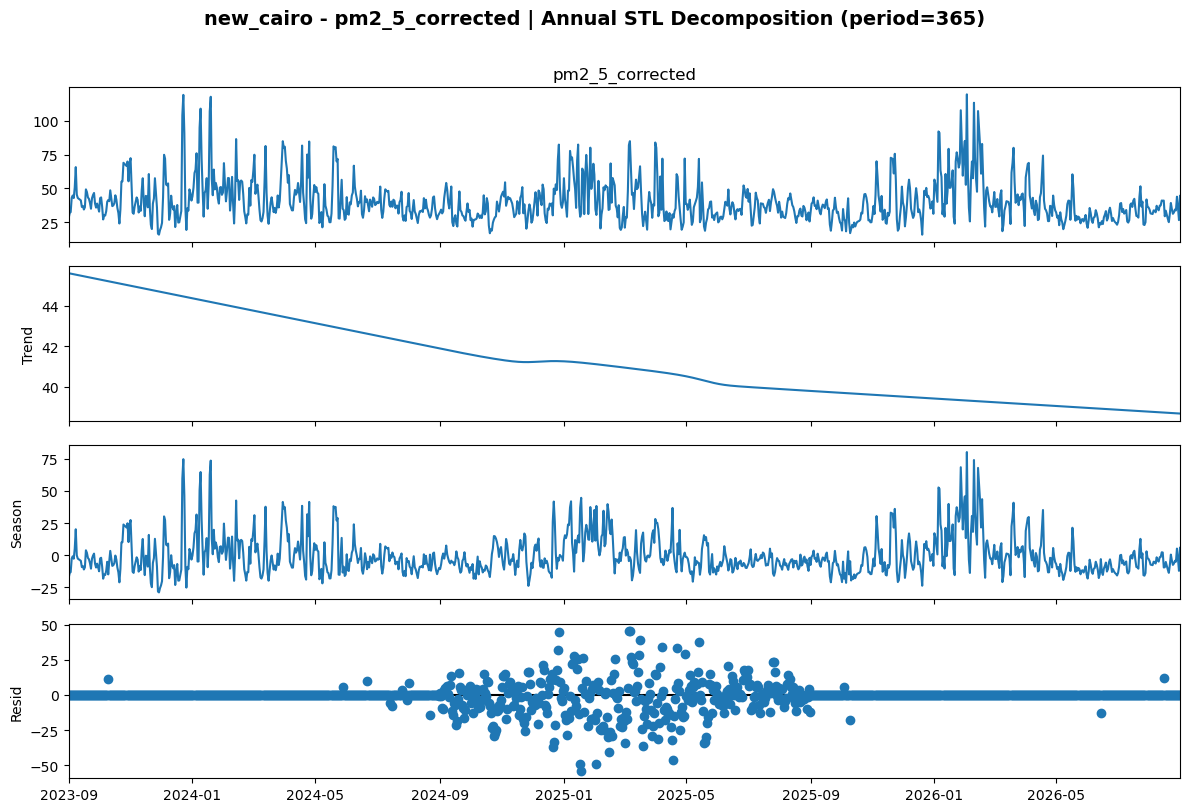

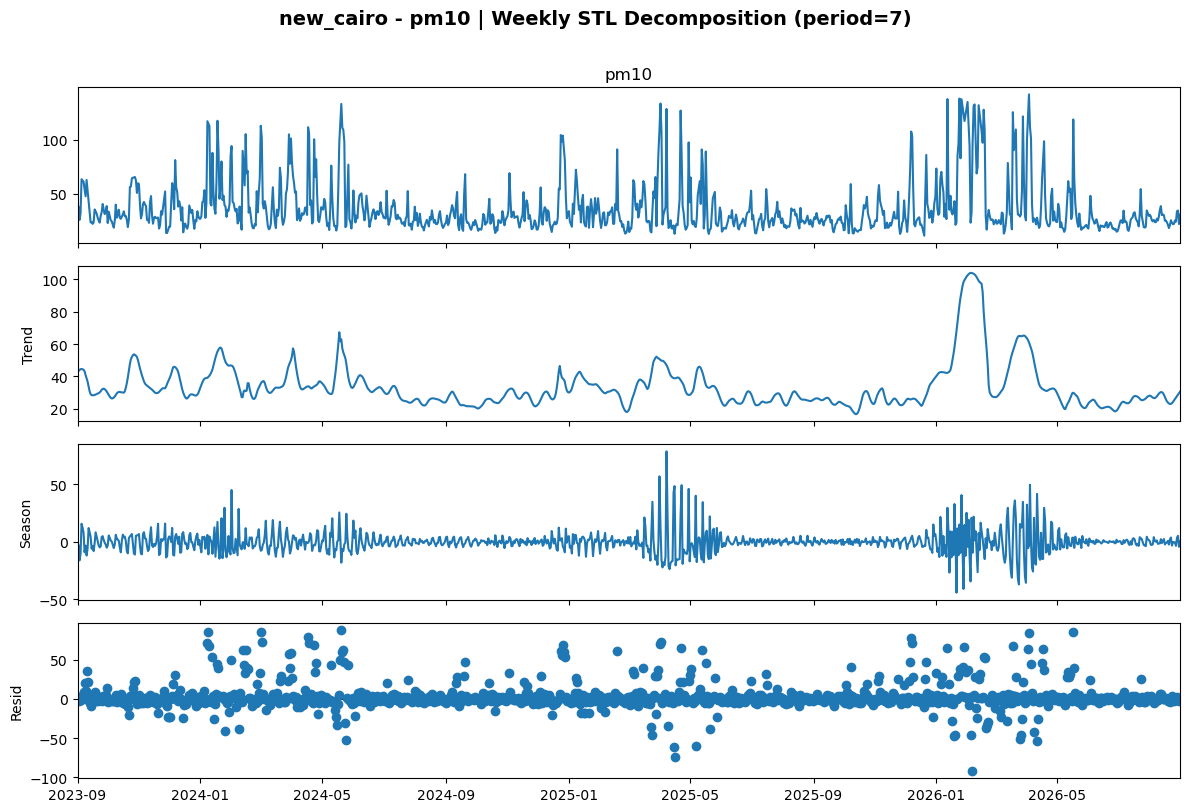

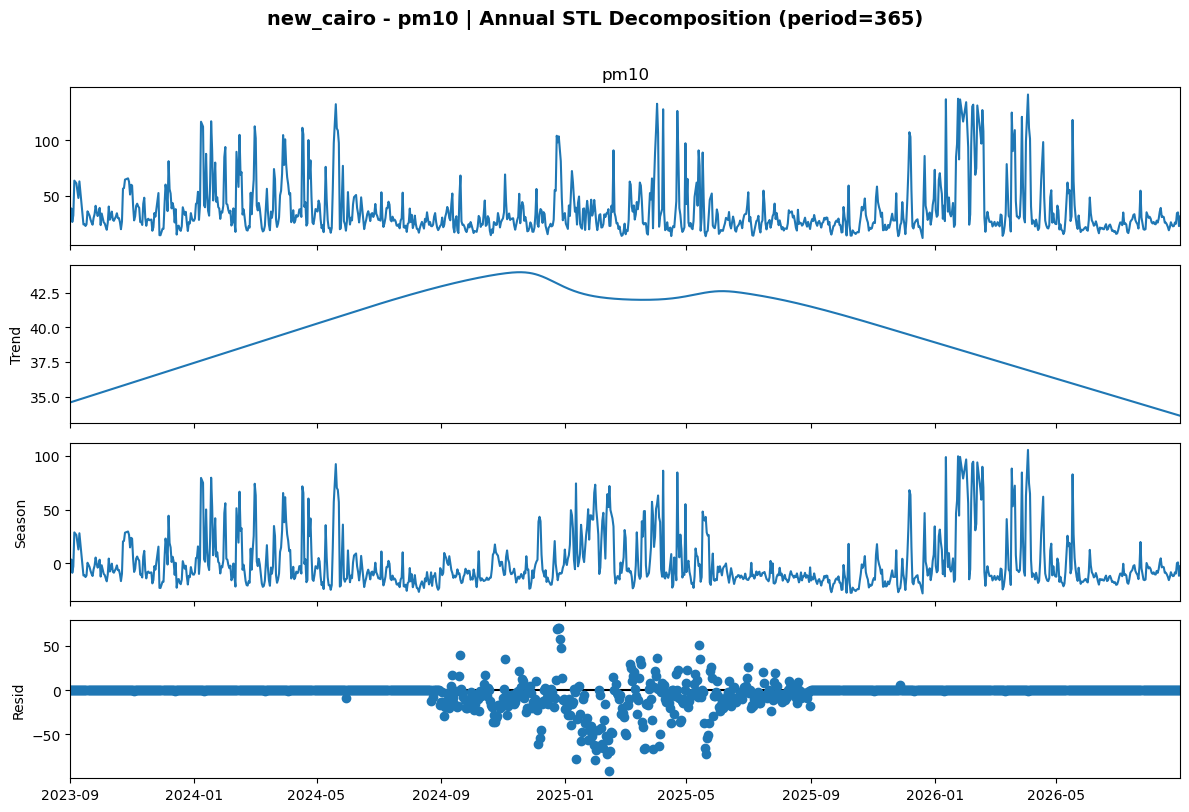

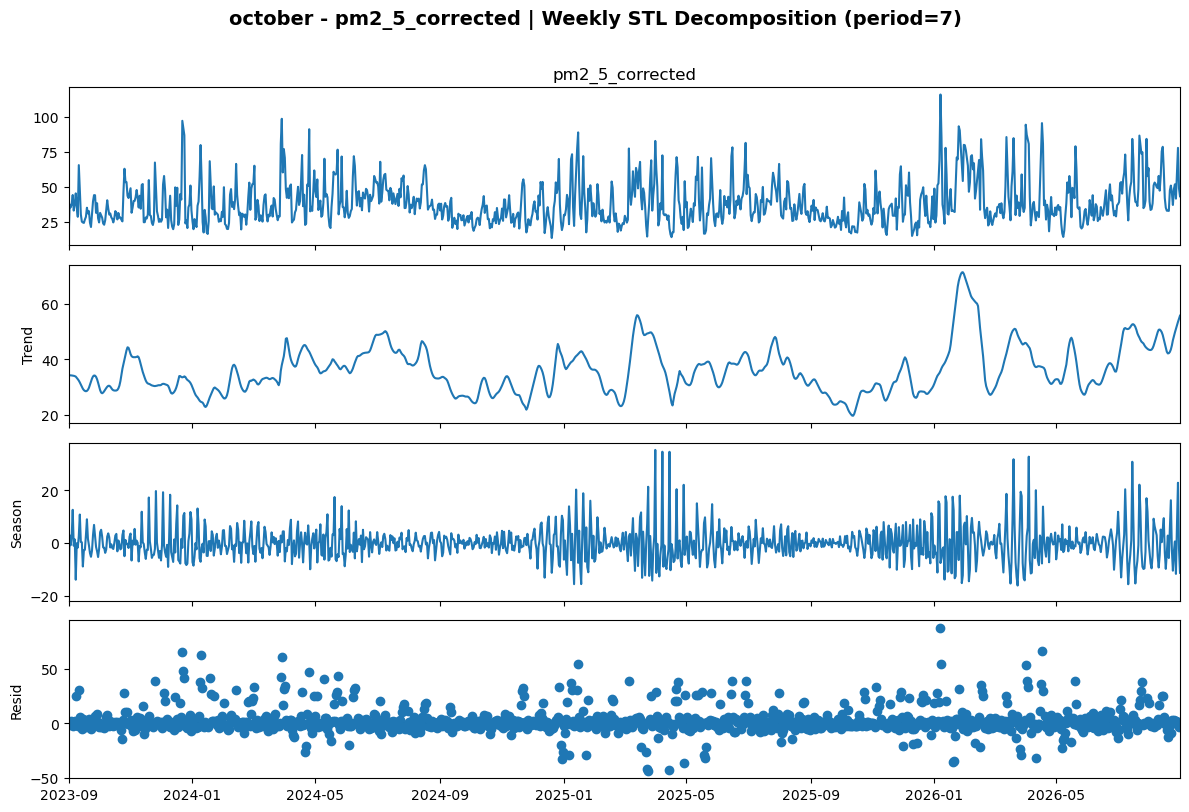

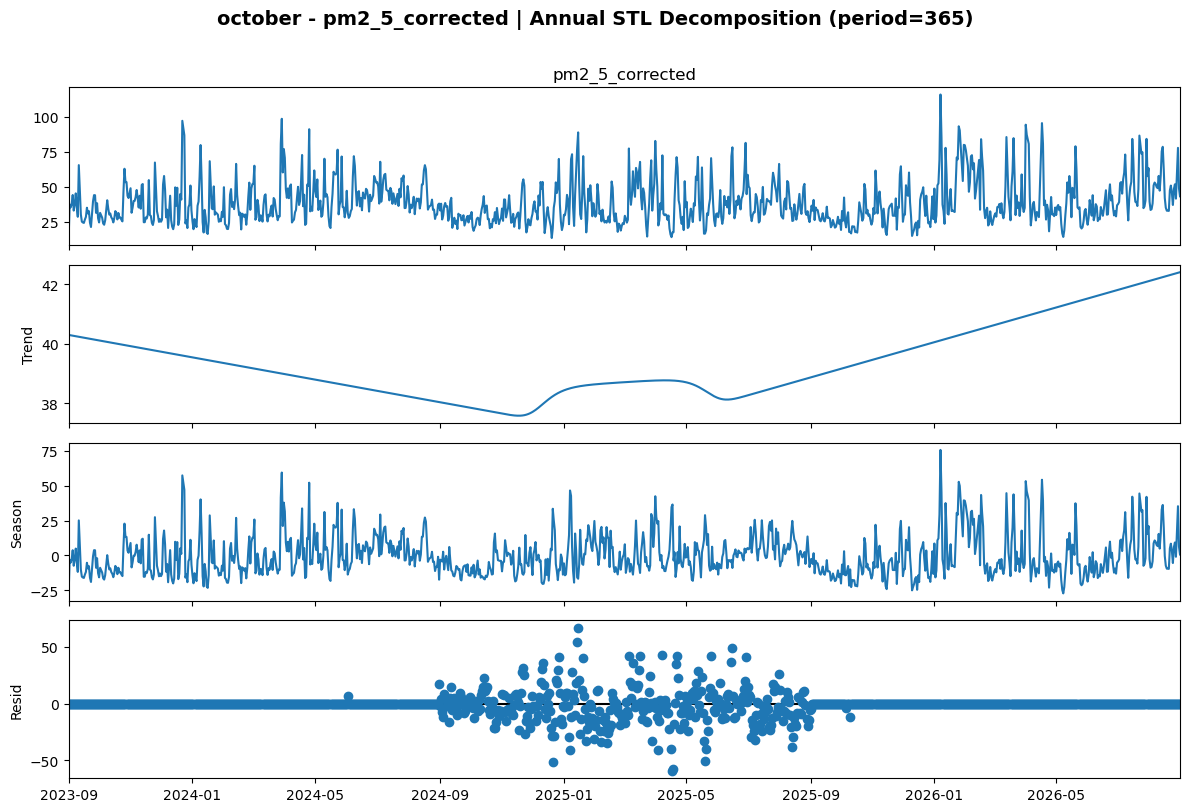

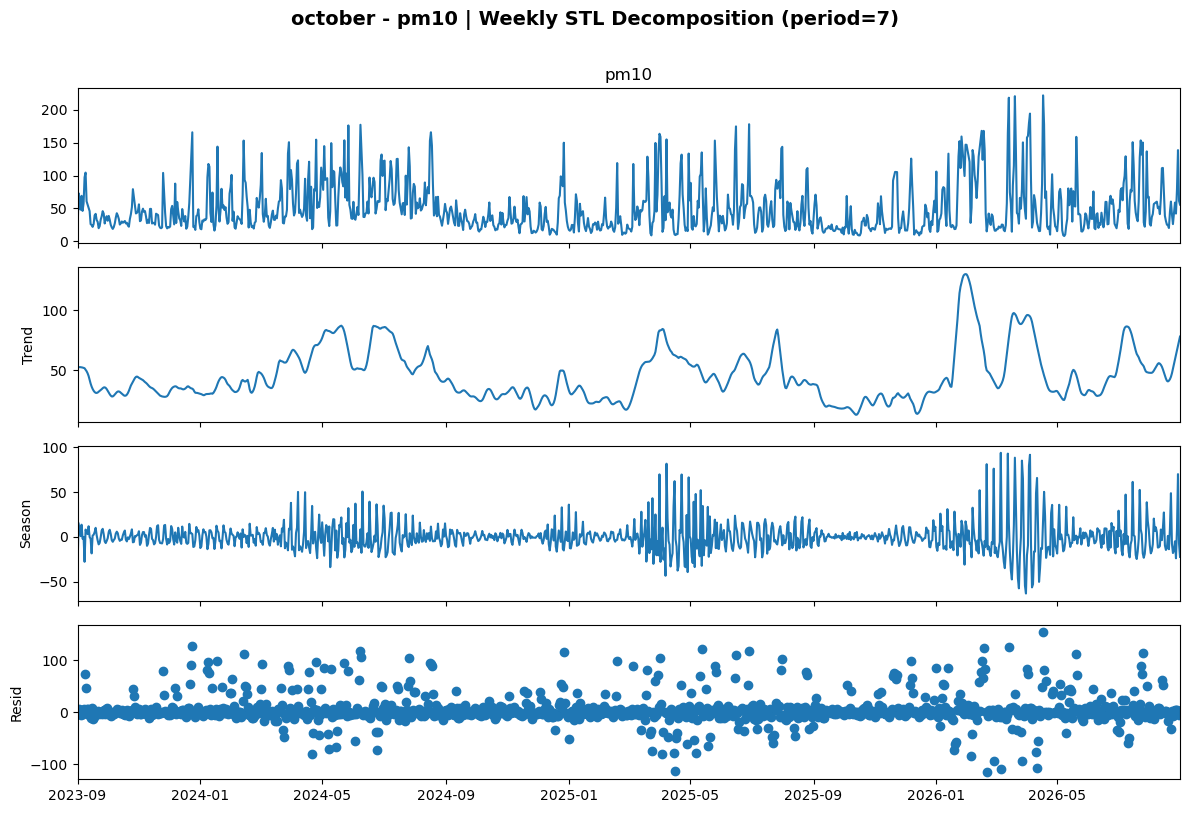

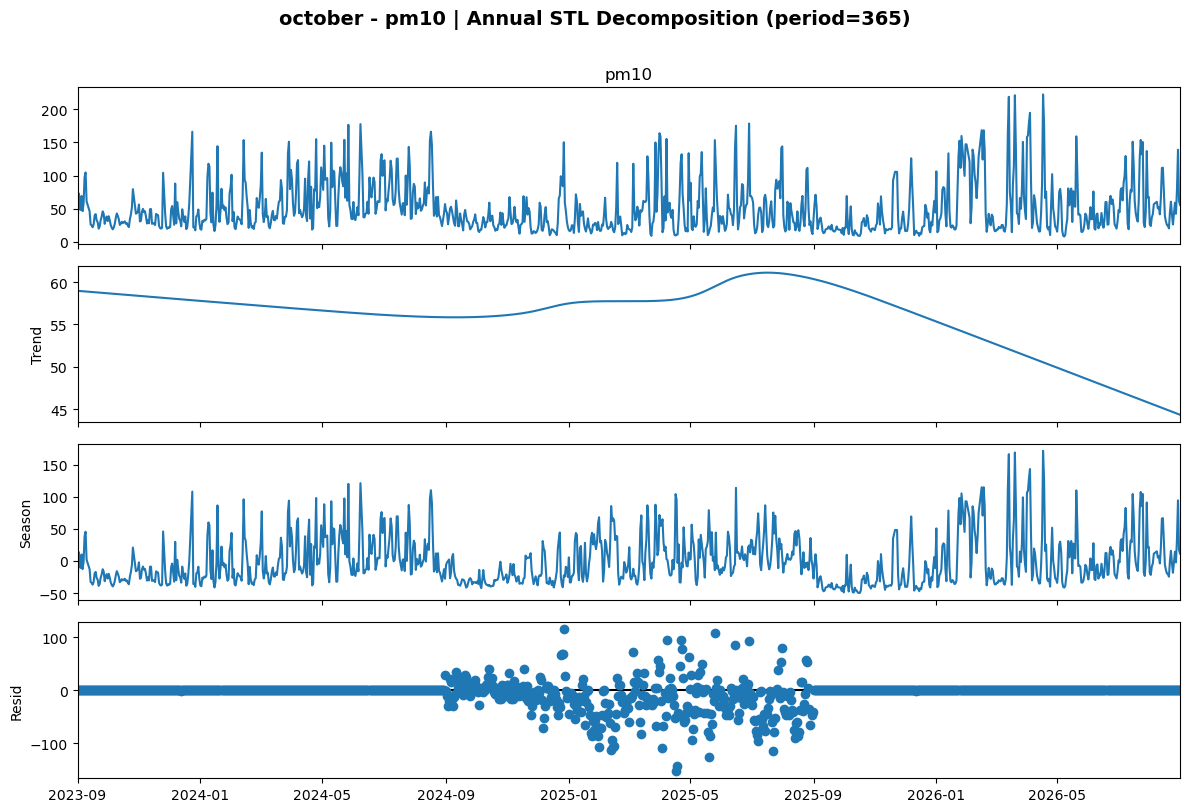

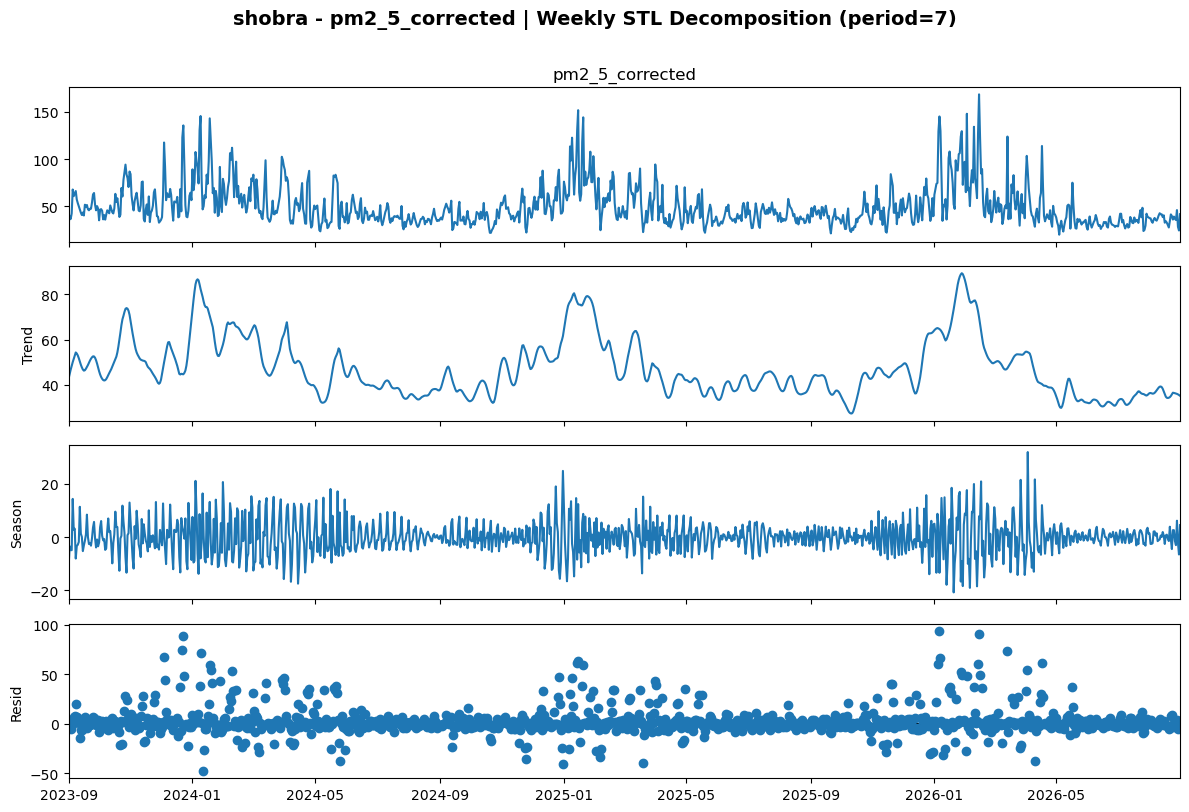

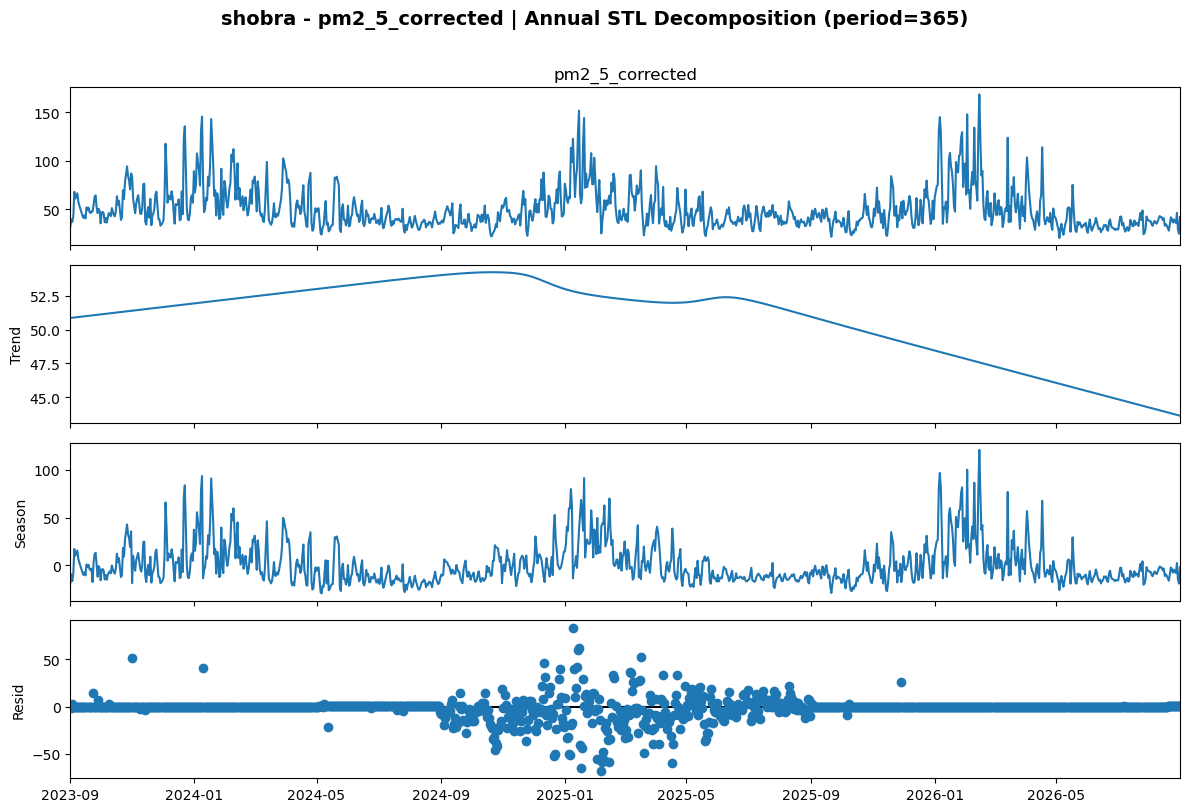

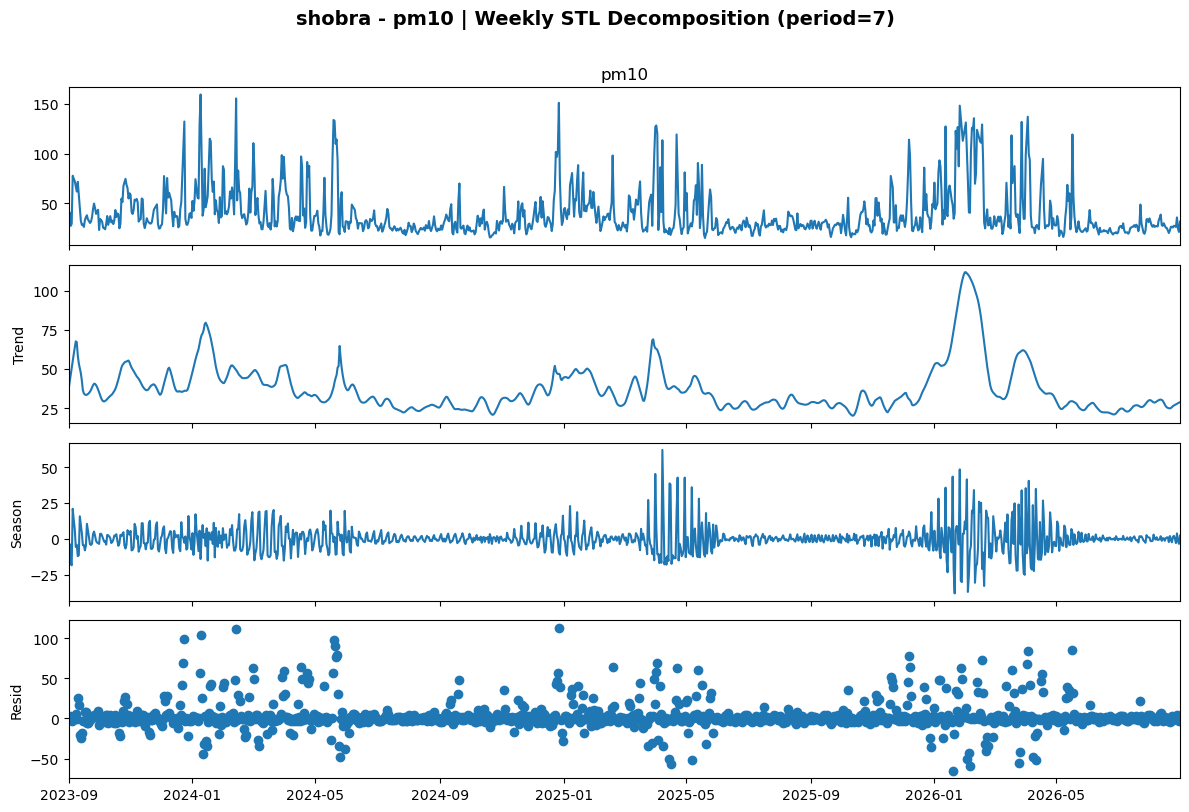

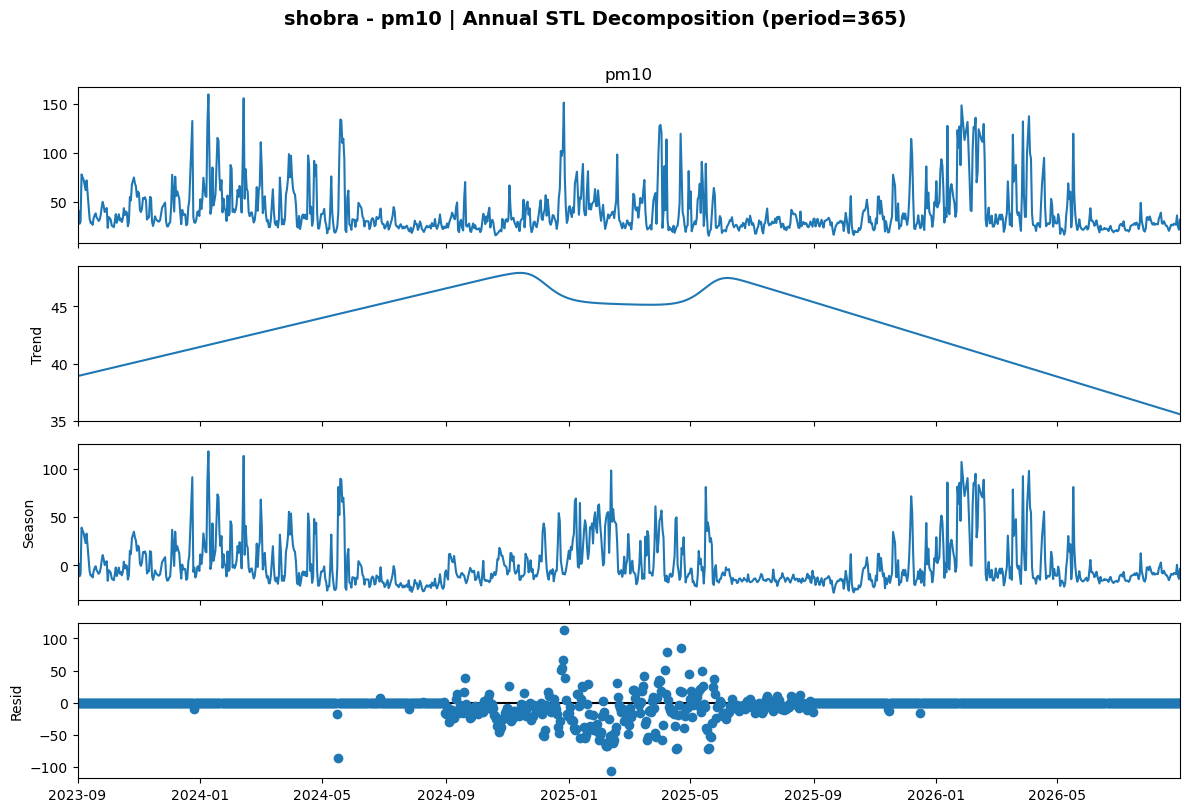

In [ ]:


for district in districts:
    district_df = daily_data[daily_data['station_id'] == district].copy()
    district_df['day'] = pd.to_datetime(district_df['day'])
    district_df = district_df.set_index('day').sort_index()

    for target in targets:
        series = district_df[target]
        # Only helwan pm2_5 will be treated as Multiplicative
        if district == 'helwan' and target == 'pm2_5_corrected':
            # 1. Transform data
            log_series = np.log1p(series)

            # 2. Weekly STL
            res_w = STL(log_series, period=7, robust=True).fit()
            plot_stl_components(
                observed=series, # original series scale
                trend=np.expm1(res_w.trend),
                seasonal=np.expm1(res_w.seasonal),
                resid=np.expm1(res_w.resid),
                title=f'{district} - {target} | Weekly STL (Multiplicative, period=7)'
            )

            # 3. Annual STL
            res_a = STL(log_series, period=365, seasonal=13, robust=True).fit()
            plot_stl_components(
                observed=series,
                trend=np.expm1(res_a.trend),
                seasonal=np.expm1(res_a.seasonal),
                resid=np.expm1(res_a.resid),
                title=f'{district} - {target} | Annual STL (Multiplicative, period=365)'
            )

        else:
            # Standard Additive Cases
            res_w = STL(series, period=7, robust=True).fit()
            fig_w = res_w.plot()
            fig_w.set_size_inches(12, 8)
            plt.suptitle(f'{district} - {target} | Weekly STL Decomposition (period=7)', y=1.01, fontsize=14, fontweight='bold')
            plt.tight_layout()
            plt.show()

            res_a = STL(series, period=365, seasonal=13, robust=True).fit()
            fig_a = res_a.plot()
            fig_a.set_size_inches(12, 8)
            plt.suptitle(f'{district} - {target} | Annual STL Decomposition (period=365)', y=1.01, fontsize=14, fontweight='bold')
            plt.tight_layout()
            plt.show()